Simulating Thermodynamics of the TSP... Please wait.
Simulation Complete. Generating Graph...


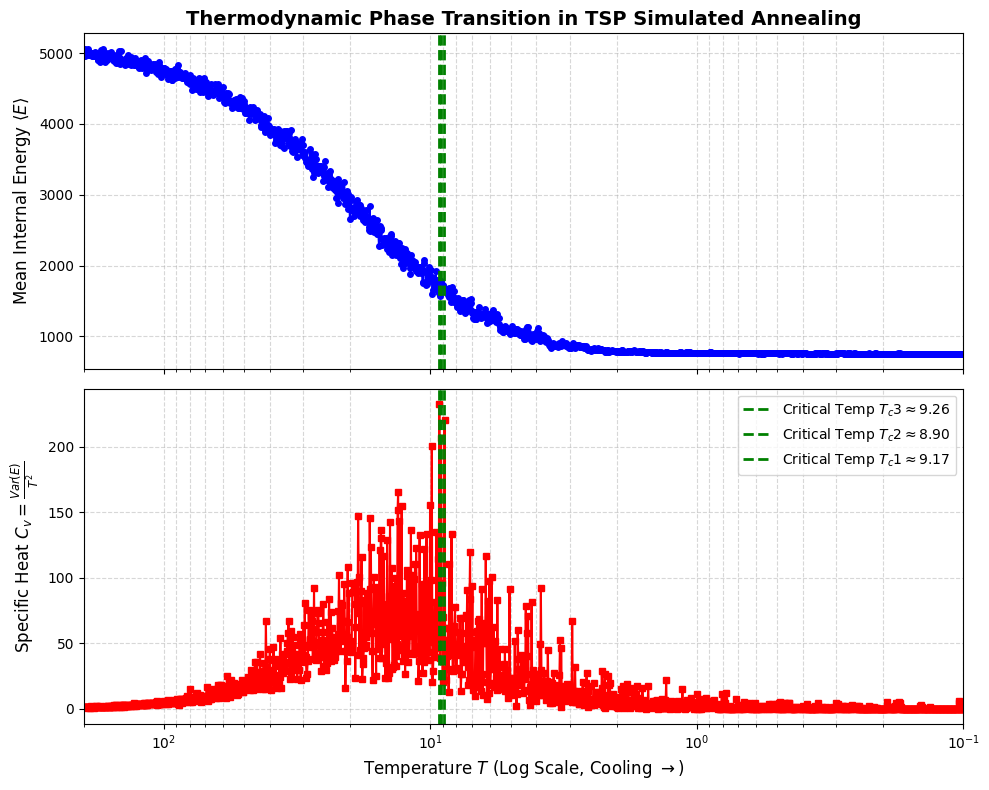

In [7]:
import numpy as np
import matplotlib.pyplot as plt

# ==========================================
# 1. TSP Setup and Helper Functions
# ==========================================
N_CITIES = 100
np.random.seed(100) # For reproducible results

# Generate random cities in a 100x100 grid
cities = np.random.rand(N_CITIES, 2) * 100

# Precompute the distance matrix
dist_matrix = np.zeros((N_CITIES, N_CITIES))
for i in range(N_CITIES):
    for j in range(N_CITIES):
        dist_matrix[i, j] = np.linalg.norm(cities[i] - cities[j])

def get_tour_length(tour):
    """Calculates the total internal energy (distance) of a given tour."""
    return sum(dist_matrix[tour[i], tour[(i+1) % N_CITIES]] for i in range(N_CITIES))

# ==========================================
# 2. Thermodynamic Simulated Annealing
# ==========================================
T_start = 200.0  # High temperature
T_end = 0.1      # Low temperature
alpha = 0.995     # Slow cooling rate to ensure thermal equilibrium
L = 3000         # Markov chain length (mixing time) at each temperature

# Initial random state
tour = np.random.permutation(N_CITIES)
current_energy = get_tour_length(tour)

# Data arrays for our thermodynamic analysis
temperatures = []
mean_energies =[]
specific_heats =[]

T = T_start

print("Simulating Thermodynamics of the TSP... Please wait.")

while T > T_end:
    energies_at_T =[]
    
    # Run the Markov Chain at the current temperature
    for _ in range(L):
        # Pick two random indices for 2-Opt
        i, j = sorted(np.random.choice(N_CITIES, 2, replace=False))
        
        # Skip edge case where we reverse the entire array
        if i == 0 and j == N_CITIES - 1:
            continue
            
        # O(1) calculation for Change in Internal Energy (Delta E)
        n1, n2 = tour[i-1], tour[i]
        n3, n4 = tour[j], tour[(j+1) % N_CITIES]
        
        dE = (dist_matrix[n1, n3] + dist_matrix[n2, n4]) - (dist_matrix[n1, n2] + dist_matrix[n3, n4])
        
        # Metropolis Acceptance Criterion
        if dE < 0 or np.random.rand() < np.exp(-dE / T):
            # Accept the move: reverse the sub-tour
            tour[i:j+1] = tour[i:j+1][::-1]
            current_energy += dE
            
        # Record the energy of the system at this step
        energies_at_T.append(current_energy)
        
    # Thermodynamic Calculations for this Temperature Epoch
    mean_E = np.mean(energies_at_T)
    var_E = np.var(energies_at_T)
    
    # Specific Heat formula: Cv = Var(E) / T^2
    Cv = var_E / (T**2)
    
    temperatures.append(T)
    mean_energies.append(mean_E)
    specific_heats.append(Cv)
    
    T *= alpha # Cool the system

print("Simulation Complete. Generating Graph...")

# ==========================================
# 3. Plotting the Phase Transition
# ==========================================
fig, (ax1, ax2) = plt.subplots(2, 1, figsize=(10, 8), sharex=True)

# Important: We reverse the X-axis so time (cooling) goes left-to-right
# and we use a log scale because temperature drops exponentially.
ax1.set_xlim(T_start, T_end)
ax1.set_xscale('log')

# Plot 1: Mean Internal Energy vs Temperature
ax1.plot(temperatures, mean_energies, color='blue', marker='o', markersize=4)
ax1.set_ylabel('Mean Internal Energy $\\langle E \\rangle$', fontsize=12)
ax1.set_title('Thermodynamic Phase Transition in TSP Simulated Annealing', fontsize=14, fontweight='bold')
ax1.grid(True, which="both", ls="--", alpha=0.5)

# Plot 2: Specific Heat vs Temperature
ax2.plot(temperatures, specific_heats, color='red', marker='s', markersize=4)
ax2.set_xlabel('Temperature $T$ (Log Scale, Cooling $\\rightarrow$)', fontsize=12)
ax2.set_ylabel('Specific Heat $C_v = \\frac{Var(E)}{T^2}$', fontsize=12)

# Highlight the Phase Transition Zone
# Find the temperature where specific heat is max
max_Cv_idx = np.argmax(specific_heats)
critical_T1 = temperatures[max_Cv_idx]

specific_heats = np.delete(specific_heats, max_Cv_idx)

max_Cv_idx = np.argmax(specific_heats)
critical_T2 = temperatures[max_Cv_idx]

specific_heats = np.delete(specific_heats, max_Cv_idx)

max_Cv_idx = np.argmax(specific_heats)
critical_T3 = temperatures[max_Cv_idx]

ax2.axvline(x=critical_T1, color='green', linestyle='--', linewidth=2, label=f'Critical Temp $T_c3 \\approx {critical_T1:.2f}$')
ax1.axvline(x=critical_T1, color='green', linestyle='--', linewidth=2)

ax2.axvline(x=critical_T2, color='green', linestyle='--', linewidth=2, label=f'Critical Temp $T_c2 \\approx {critical_T2:.2f}$')
ax1.axvline(x=critical_T2, color='green', linestyle='--', linewidth=2)

ax2.axvline(x=critical_T3, color='green', linestyle='--', linewidth=2, label=f'Critical Temp $T_c1 \\approx {critical_T3:.2f}$')
ax1.axvline(x=critical_T3, color='green', linestyle='--', linewidth=2)

ax2.legend()
ax2.grid(True, which="both", ls="--", alpha=0.5)

plt.tight_layout()
plt.show()

/tmp/ipykernel_9613/3015909600.py:56: UserWarning: Tight layout not applied. The left and right margins cannot be made large enough to accommodate all axes decorations.
  plt.tight_layout()


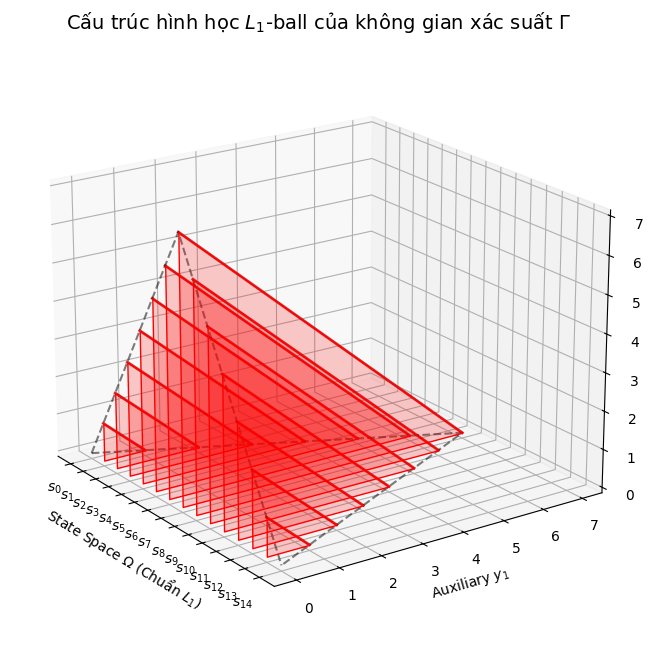

In [1]:
import matplotlib.pyplot as plt
import numpy as np
import mpl_toolkits.mplot3d.art3d as art3d

# 1. Thiết lập không gian trạng thái Omega (15 điểm)
m = 15
omega_indices = np.arange(m)
mid = 7

# 2. Định nghĩa hàm năng lượng E_i theo chuẩn L1 (Tuyến tính)
# E_i là khoảng cách đi bộ từ điểm trung tâm
energies = np.abs(omega_indices - mid) 

# 3. Đặt C = max(E_i) để xác suất triệt tiêu tại hai đầu
C = energies.max()

# 4. Trực quan hóa 3D
fig = plt.figure(figsize=(12, 8))
ax = fig.add_subplot(111, projection='3d')

for i in range(m):
    E_i = energies[i]
    L = C - E_i  # Chiều dài của Simplex phụ trợ
    
    x_coord = omega_indices[i]
    # Tọa độ cho đoạn thẳng y1 + y2 = L
    y1 = np.array([L, 0])
    y2 = np.array([0, L])
    x = np.array([x_coord, x_coord])
    
    # Vẽ các cạnh của "lớp vỏ" Gamma
    ax.plot(x, y1, y2, color='#CC0000', linewidth=2, alpha=0.8) # Màu đỏ để nhấn mạnh L1
    
    # Vẽ mặt phẳng tam giác (thể hiện thiết diện volume)
    verts = [(x_coord, 0, 0), (x_coord, L, 0), (x_coord, 0, L)]
    poly = art3d.Poly3DCollection([verts], color='red', alpha=0.2)
    ax.add_collection3d(poly)

# 5. Vẽ "Đường bao" (Envelope) để thấy rõ dạng L1-ball
# Đường nối các đỉnh cao nhất của các tam giác
ax.plot(omega_indices, C - energies, np.zeros(m), color='black', linestyle='--', alpha=0.5)
ax.plot(omega_indices, np.zeros(m), C - energies, color='black', linestyle='--', alpha=0.5)

# Định dạng
ax.set_title(r'Cấu trúc hình học $L_1$-ball của không gian xác suất $\Gamma$', fontsize=14)
ax.set_xlabel(r'State Space $\Omega$ (Chuẩn $L_1$)', fontsize=10)
ax.set_ylabel(r'Auxiliary $y_1$', fontsize=10)
ax.set_zlabel(r'Auxiliary $y_2$', fontsize=10)

ax.set_xticks(omega_indices)
ax.set_xticklabels([f'$s_{{{i}}}$' for i in range(m)])

# Điều chỉnh góc nhìn để thấy rõ hình khối "mái lều" (Tent shape) của L1
ax.view_init(elev=20, azim=-35)

plt.tight_layout()
plt.show()